# PdO on HfO₂ — thickness study: measurement noise & the XRD amorphousness objective

The fab team delivered a controlled **single-factor thickness study**: five films (final
thickness 13, 11, 9, 7, 5 nm) fabricated at otherwise **identical** process conditions, each
Hall-measured **3 times** ("noise analysis"), plus one XRD pattern per film
(`raw_data_received/noise_analysis/`). Their observations: *PdO crystallinity is related to film
thickness — 5 nm films are amorphous*, and *5 nm films require multiple measurements since the
carrier concentration reads negative most of the time (film decomposition after vacuum
annealing)* — i.e. the delivered 5 nm numbers are the valid subset of more attempts.

This notebook uses the delivery for three things:

1. **Quantify the measurement noise** (per-thickness mean, std, CV, and the SEM² observation
   variance that feeds the campaign GP via `train_Yvar` — computed with the campaign's own
   `utils.mobo.variance_of_mean_by_group`).
2. **Compute the new XRD objective on real data** — the integrated PdO(101) intensity at
   2θ = 33–35° above background — and test the crystallinity-vs-thickness claim.
3. **Thickness trends** for mobility / carrier concentration / crystallinity, i.e. a first look
   at the mobility–amorphousness trade-off on measured films.

In [1]:
import os, sys, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')

REPO_ROOT = '/data/zhq7531/IDEAL/DMREF/repository_dmref'
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
from utils.mobo import variance_of_mean_by_group

RAW = 'raw_data_received/noise_analysis'
OUT_DIR = 'output/pdo_thickness_noise_analysis'
os.makedirs(OUT_DIR, exist_ok=True)
sns.set_theme(style='whitegrid')
print('Outputs ->', OUT_DIR)

Outputs -> output/pdo_thickness_noise_analysis


## 1. Load the delivery

In [2]:
# Hall replicates (Sheet1) — thickness label applies to the 3 rows below it
raw = pd.read_excel(os.path.join(RAW, 'noise_analysis.xlsx'), header=None, skiprows=1,
                    names=['thickness', 'mobility', 'carrier'])
raw['thickness'] = raw['thickness'].ffill().str.replace('nm', '').astype(int)
raw['mobility'] = raw['mobility'].astype(float)
raw['carrier'] = raw['carrier'].astype(float)
hall = raw.reset_index(drop=True)
hall['replicate'] = hall.groupby('thickness').cumcount() + 1

# Process conditions (Sheet2) — identical across films except thickness
cond = pd.read_excel(os.path.join(RAW, 'noise_analysis.xlsx'), sheet_name='Sheet2')
ratio = (cond['Final Thickness (nm)'] / cond['Deposition Thickness (nm)']).round(3).unique()
print(f'{hall.thickness.nunique()} thicknesses x 3 replicates = {len(hall)} Hall measurements')
print(f'Shared conditions: Ox {cond["Oxidation Temperature (°C)"].iloc[0]:g} °C / '
      f'{cond["Oxidation Time (min)"].iloc[0]:g} min at {cond["Oxidation Pressure (atm)"].iloc[0]:g} atm, '
      f'Vac Ann {cond["Vacuum Annealing Temperature (°C)"].iloc[0]:g} °C / '
      f'{cond["Vacuum Annealing Time (min)"].iloc[0]:g} min  (within the 300 °C cap)')
print(f'Oxidation thickness expansion: final/deposited = {ratio} (≈ 5/3 for every film)')
cond

5 thicknesses x 3 replicates = 15 Hall measurements
Shared conditions: Ox 500 °C / 1.1 min at 0.02 atm, Vac Ann 217.4 °C / 29.1 min  (within the 300 °C cap)
Oxidation thickness expansion: final/deposited = [1.667] (≈ 5/3 for every film)


,Deposition Power (W),O2 Flow rate during deposition (sccm),Deposition Pressure (mTorr),Deposition Temperature (°C),Oxidation Temperature (°C),Oxidation Pressure (atm),Oxidation Time (min),Vacuum Annealing Temperature (°C),Vacuum Annealing Time (min),Deposition Thickness (nm),Final Thickness (nm)
0,36,13.4,6.3,425,500,0.02,1.1,217.4,29.1,7.8,13
1,36,13.4,6.3,425,500,0.02,1.1,217.4,29.1,6.6,11
2,36,13.4,6.3,425,500,0.02,1.1,217.4,29.1,5.4,9
3,36,13.4,6.3,425,500,0.02,1.1,217.4,29.1,4.2,7
4,36,13.4,6.3,425,500,0.02,1.1,217.4,29.1,3.0,5


**Note on the expansion factor.** Final thickness is consistently **5/3 × deposited
thickness** (Pd → PdO volume expansion). The campaign DoE sweeps *deposited* thickness 2–6 nm,
which therefore corresponds to **~3.3–10 nm final** — the design brackets the
amorphous-to-crystalline transition this study probes.

## 2. Measurement noise — the reason for replicates

Per-thickness statistics for both responses, including the **SEM² observation variance**
(`var(replicates)/n`) that the campaign GP consumes as `train_Yvar`. Carrier concentration is
also summarized in log₁₀ (the GP will model it in log space given its dynamic range).

In [12]:
g = hall.groupby('thickness')
stats = pd.DataFrame({
    'mob mean':  g['mobility'].mean().round(2),
    'mob std':   g['mobility'].std().round(2),
    'mob CV %':  (100 * g['mobility'].std() / g['mobility'].mean()).round(0),
    'car mean':  g['carrier'].mean().map('{:.2e}'.format),
    'car CV %':  (100 * g['carrier'].std() / g['carrier'].mean()).round(0),
}).sort_index(ascending=False)

stats['mob SEM^2']      = variance_of_mean_by_group(hall, 'thickness', 'mobility').round(2)
stats['log10car SEM^2'] = variance_of_mean_by_group(hall, 'thickness', 'carrier',
                                                    transform=np.log10).round(4)
stats.to_excel(os.path.join(OUT_DIR, 'noise_statistics.xlsx'))
display('CV = std/mean per condition; SEM^2 = var/n = GP observation variance (train_Yvar)')
stats

'CV = std/mean per condition; SEM^2 = var/n = GP observation variance (train_Yvar)'

,mob mean,mob std,mob CV %,car mean,car CV %,mob SEM^2,log10car SEM^2
thickness,,,,,,,
13,7.30,6.35,87.0,3.57e+19,43.0,13.46,0.0167
11,7.86,3.80,48.0,9.26e+19,21.0,4.81,0.0029
9,8.61,4.68,54.0,6.73e+19,67.0,7.30,0.0348
7,6.51,4.91,75.0,1.69e+20,129.0,8.02,0.1107
5,15.26,5.33,35.0,1.22e+19,44.0,9.48,0.0141


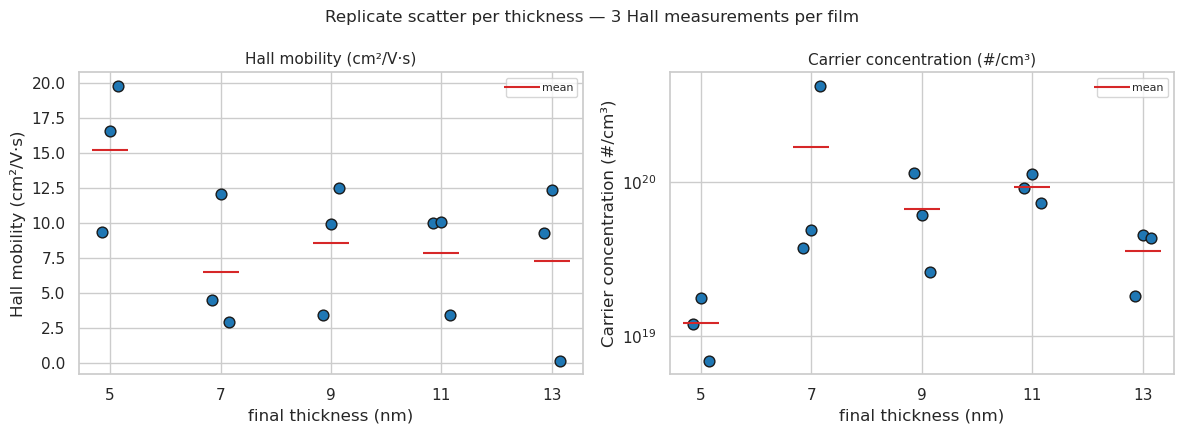

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
th = sorted(hall.thickness.unique())
for ax, col, ylab, logy in [(axes[0], 'mobility', 'Hall mobility (cm²/V·s)', False),
                            (axes[1], 'carrier', 'Carrier concentration (#/cm³)', True)]:
    for t in th:
        v = hall.loc[hall.thickness == t, col]
        x = np.full(len(v), t) + np.linspace(-0.15, 0.15, len(v))
        ax.scatter(x, v, s=60, color='#1f77b4', edgecolor='k', zorder=3)
        ax.scatter([t], [v.mean()], marker='_', s=700, color='#d62728', zorder=4,
                   label='mean' if t == th[0] else None)
    if logy: ax.set_yscale('log')
    ax.set_xticks(th); ax.set_xlabel('final thickness (nm)'); ax.set_ylabel(ylab)
    ax.set_title(ylab, fontsize=11); ax.legend(fontsize=8)
fig.suptitle('Replicate scatter per thickness — 3 Hall measurements per film', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'replicate_scatter.png'), dpi=180, bbox_inches='tight')
plt.show()

**Caveat (survivorship at 5 nm).** Per the fab team, thin films read *negative* carrier
concentration in most attempts (decomposition after vacuum annealing, even at 217 °C) and the
delivered 5 nm values are the measurements that succeeded. The 5 nm statistics are therefore
conditioned on measurement success — the true film-to-film variability at 5 nm is larger than
these three points suggest, and thin-film feasibility is partly thickness-driven, not only
anneal-temperature-driven.

## 3. XRD — computing the amorphousness objective on real patterns

One pattern per film. The new campaign objective is the **integrated intensity of the PdO(101)
reflection in the 2θ = 33–35° window above background** (background = linear baseline fitted to
the flanking windows 31.5–32.5° and 35.5–36.5°). Lower = more amorphous.

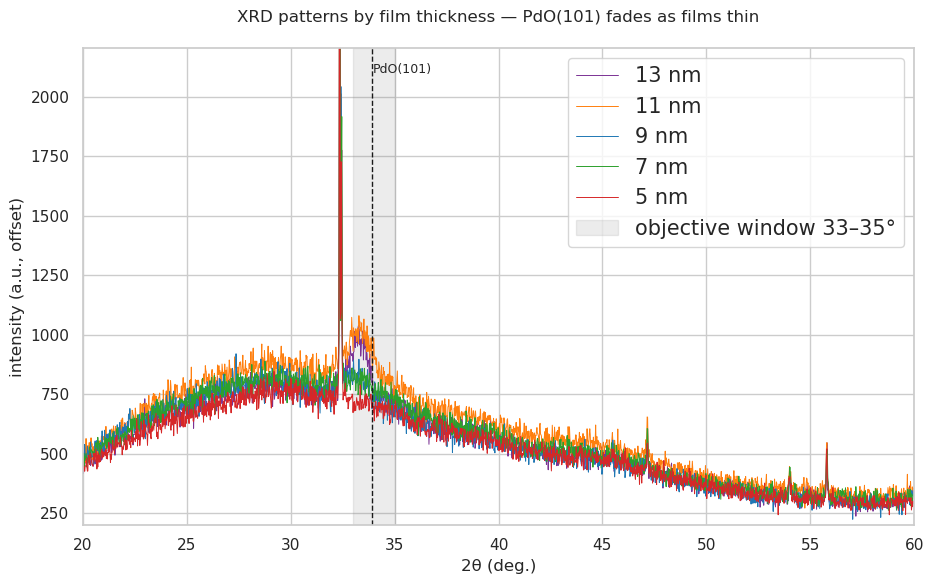

In [11]:
xr = pd.read_excel(os.path.join(RAW, 'xrd.xlsx'), header=None, skiprows=1)
labels = [13, 11, 9, 7, 5]
xrd = {}
for i, t in enumerate([5, 7, 9, 11, 13]):        # column pairs as delivered: 5,7,9,11,13 nm
    tt = xr.iloc[:, 2 * i].astype(float).values
    ii = xr.iloc[:, 2 * i + 1].astype(float).values
    m = np.isfinite(tt) & np.isfinite(ii)
    xrd[t] = (tt[m], ii[m])

# NOTE: patterns run 20-80°; the substrate reflections near 61° and 68-69° reach ~2e6 counts
# (vs ~600 counts of film signal) and would flatten the plot. Display 20-60° with a clipped
# y-scale, like the fab team's slide — the 33-35° objective window holds only film-level
# intensity (max ~1000 counts), so the AUC metric is unaffected.
colors = {13: '#7b3294', 11: '#ff7f0e', 9: '#1f77b4', 7: '#2ca02c', 5: '#d62728'}
OFF = 1
fig, ax = plt.subplots(figsize=(9.5, 6))
for k, t in enumerate(labels):
    tt, ii = xrd[t]
    m = (tt >= 20) & (tt <= 60)
    ax.plot(tt[m], ii[m] + OFF * k, lw=0.7, color=colors[t], label=f'{t} nm')
ax.set_xlim(20, 60); ax.set_ylim(200, OFF * len(labels) + 2200)
ax.axvspan(33, 35, color='gray', alpha=0.15, label='objective window 33–35°')
ax.axvline(33.9, ls='--', color='k', lw=1)
ax.text(33.95, ax.get_ylim()[1] * 0.97, 'PdO(101)', fontsize=9, va='top')
ax.set_xlabel('2θ (deg.)'); ax.set_ylabel('intensity (a.u., offset)')
ax.set_title('XRD patterns by film thickness — PdO(101) fades as films thin\n')
            #  '(20–60° shown; substrate reflections at ~61°/68° clipped)')
ax.legend(fontsize=15, loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'xrd_stacked.png'), dpi=180, bbox_inches='tight')
plt.show()

In [6]:
def pdo101_metrics(tt, ii, win=(33.0, 35.0), bg1=(31.5, 32.5), bg2=(35.5, 36.5)):
    """(AUC above background, peak height above background) for the PdO(101) window."""
    def med(w):
        m = (tt >= w[0]) & (tt <= w[1]); return float(np.median(tt[m])), float(np.median(ii[m]))
    (x1, y1), (x2, y2) = med(bg1), med(bg2)
    m = (tt >= win[0]) & (tt <= win[1])
    base = y1 + (y2 - y1) * (tt[m] - x1) / (x2 - x1)
    excess = np.clip(ii[m] - base, 0, None)
    return float(np.trapz(excess, tt[m])), float(excess.max())

rows = []
for t in labels:
    auc, height = pdo101_metrics(*xrd[t])
    rows.append({'thickness (nm)': t, 'PdO(101) AUC 33-35°': round(auc, 1),
                 'AUC / thickness': round(auc / t, 2), 'peak height (cts)': round(height, 1)})
xrd_tbl = pd.DataFrame(rows)
xrd_tbl.to_excel(os.path.join(OUT_DIR, 'xrd_pdo101_metrics.xlsx'), index=False)
xrd_tbl

,thickness (nm),PdO(101) AUC 33-35°,AUC / thickness,peak height (cts)
0,13,219.5,16.88,295.7
1,11,226.2,20.56,260.5
2,9,110.0,12.22,168.1
3,7,86.9,12.42,110.1
4,5,30.7,6.14,79.2


## 4. Thickness trends — the trade-off in one figure

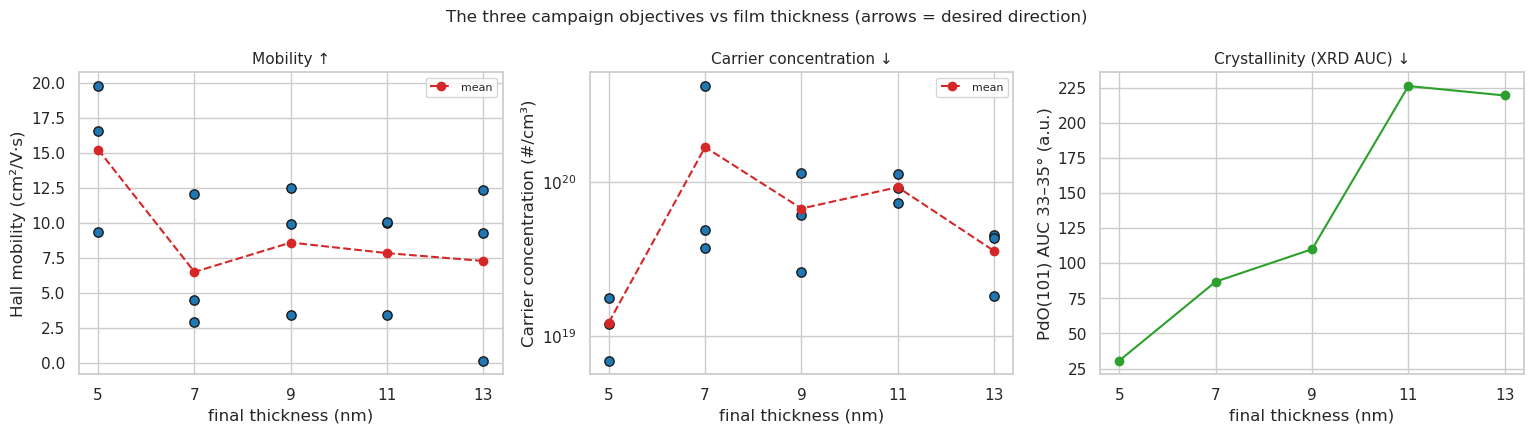

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.4))
mm = hall.groupby('thickness')['mobility'].mean()
cm = hall.groupby('thickness')['carrier'].mean()
auc = xrd_tbl.set_index('thickness (nm)')['PdO(101) AUC 33-35°']

axes[0].scatter(hall.thickness, hall.mobility, s=45, color='#1f77b4', edgecolor='k', zorder=3)
axes[0].plot(mm.index, mm.values, 'o--', color='#d62728', label='mean', zorder=4)
axes[0].set_ylabel('Hall mobility (cm²/V·s)'); axes[0].set_title('Mobility ↑', fontsize=11)
axes[1].scatter(hall.thickness, hall.carrier, s=45, color='#1f77b4', edgecolor='k', zorder=3)
axes[1].plot(cm.index, cm.values, 'o--', color='#d62728', label='mean', zorder=4)
axes[1].set_yscale('log'); axes[1].set_ylabel('Carrier concentration (#/cm³)')
axes[1].set_title('Carrier concentration ↓', fontsize=11)
axes[2].plot(auc.index, auc.values, 'o-', color='#2ca02c')
axes[2].set_ylabel('PdO(101) AUC 33–35° (a.u.)'); axes[2].set_title('Crystallinity (XRD AUC) ↓', fontsize=11)
for ax in axes:
    ax.set_xlabel('final thickness (nm)'); ax.set_xticks(sorted(hall.thickness.unique()))
    if ax.get_legend_handles_labels()[0]: ax.legend(fontsize=8)
fig.suptitle('The three campaign objectives vs film thickness (arrows = desired direction)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'objectives_vs_thickness.png'), dpi=180, bbox_inches='tight')
plt.show()

## 5. Findings

1. **The noise is large and response-dependent — replicates are not optional.** Mobility CV runs
   35–87 % per condition (the 13 nm film's three measurements span 0.18 to 12.4 cm²/V·s);
   carrier concentration CV runs 21–129 % (the 7 nm set contains a 4.2×10²⁰ outlier). The SEM²
   table above feeds directly into the GP's `train_Yvar`; carrier concentration should be
   modeled in log space (log₁₀ SEM² of 0.003–0.11). This scatter is exactly why the campaign
   uses noise-aware acquisitions (qNEI/qLogNEHVI) rather than plain EI.
2. **The XRD 33–35° AUC works as the amorphousness objective.** The PdO(101) integrated
   intensity falls from ≈ 220–226 (13/11 nm) through 110 → 87 (9/7 nm) to **31 at 5 nm** — a
   7× drop that ranks the films exactly as the fab team's crystallinity claim. The
   thickness-normalized AUC also drops ~3×, so the thin film is genuinely more amorphous, not
   merely thinner. The proposed window (~34°, PdO(101)) is a practical, computable objective.
3. **In this delivery the 5 nm amorphous film wins on *all three* objectives** — highest mean
   mobility (15.3 cm²/V·s), lowest carrier concentration (1.2×10¹⁹ cm⁻³), lowest crystallinity
   (AUC 31). That is more optimistic than the earlier crystalline-vs-amorphous slide
   (14.6 vs 5.5 cm²/V·s) — if it holds, the mobility–amorphousness trade-off may be milder than
   assumed. Two cautions: each thickness is a *single film* (the replicates are repeated
   measurements, not repeated fabrications), and the 5 nm numbers are **survivorship-filtered**
   — most 5 nm measurement attempts read negative carrier concentration (decomposition after
   vacuum annealing, even at 217 °C).
4. **Campaign implications.** (a) The DoE's deposited-thickness range 2–6 nm maps to ~3.3–10 nm
   final via the 5/3 oxidation expansion — it brackets the amorphous transition, with 5 nm
   final ≈ 3 nm deposited near the design's lower edge. (b) Feasibility is partly
   *thickness*-driven, not only anneal-temperature-driven — measurement failures at small
   thickness should be logged and fed to the feasibility model alongside contact failures.
   (c) Report per-condition SEM² with every delivery; three replicates is the workable minimum
   at these noise levels.